In [1]:
# GLOBAL POPULATION & ECONOMY — EDA CODE
# Pandas + NumPy + Matplotlib + Seaborn

In [2]:
# GLOBAL POPULATION & ECONOMY — EDA CODE
# Pandas + NumPy + Matplotlib + Seaborn
# Dataset: global_population_economy.csv
# 650 rows | 25 countries | 2000-2025
# Columns: country, continent, year, population_millions,
#          gdp_per_capita_usd, gdp_total_billion_usd,
#          life_expectancy, urbanization_rate_pct, unemployment_rate_pct

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [6]:
# Q1: Load and inspect the data
df = pd.read_csv("global_population.csv")
print(df.shape)
df.head()

(650, 9)


,country,continent,year,population_millions,gdp_per_capita_usd,gdp_total_billion_usd,life_expectancy,urbanization_rate_pct,unemployment_rate_pct
0,United States,North America,2000,325.77,60592.0,19739.0,78.0,82.0,9.9
1,United States,North America,2001,327.78,61282.3,20087.0,78.1,82.2,7.9
2,United States,North America,2002,327.46,62518.5,20472.2,78.3,82.3,3.7
3,United States,North America,2003,337.56,63760.1,21522.6,78.5,82.4,2.5
4,United States,North America,2004,338.01,66083.4,22336.9,79.0,83.7,4.5


In [7]:
# Q2: Check data types and structure
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 650 entries, 0 to 649
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   country                650 non-null    str    
 1   continent              650 non-null    str    
 2   year                   650 non-null    int64  
 3   population_millions    650 non-null    float64
 4   gdp_per_capita_usd     650 non-null    float64
 5   gdp_total_billion_usd  650 non-null    float64
 6   life_expectancy        650 non-null    float64
 7   urbanization_rate_pct  650 non-null    float64
 8   unemployment_rate_pct  637 non-null    float64
dtypes: float64(6), int64(1), str(2)
memory usage: 45.8 KB


In [8]:
# Q3: Check missing values
print(df.isnull().sum())

country                   0
continent                 0
year                      0
population_millions       0
gdp_per_capita_usd        0
gdp_total_billion_usd     0
life_expectancy           0
urbanization_rate_pct     0
unemployment_rate_pct    13
dtype: int64


In [10]:
# Q4: Fill missing unemployment_rate_pct with the column median
df['unemployment_rate_pct'] = df['unemployment_rate_pct'].fillna(
    df['unemployment_rate_pct'].median()
)

In [11]:
# Q5: Use NumPy to find min, max, mean of gdp_per_capita_usd
gdp_pc = df['gdp_per_capita_usd'].to_numpy()
print("Min:", np.min(gdp_pc))
print("Max:", np.max(gdp_pc))
print("Mean:", np.mean(gdp_pc))

Min: 1426.9
Max: 231466.1
Mean: 33008.10215384615


In [13]:
# Q6: Find total number of unique countries and continents
print("Countries:", df['country'].nunique())
print("Continents:", df['continent'].nunique()

_IncompleteInputError: incomplete input (2444761743.py, line 3)

In [14]:
# Q7: Find the top 5 countries by GDP per capita in the latest year (2025)
latest = df[df['year'] == df['year'].max()]
top_gdp_pc = latest.sort_values('gdp_per_capita_usd', ascending=False).head(5)
print(top_gdp_pc[['country', 'gdp_per_capita_usd']])

            country  gdp_per_capita_usd
311          Canada            172884.2
155         Germany            135545.2
233           Japan            108811.0
181  United Kingdom            108436.4
441       Australia             92770.6


In [15]:
# Q8: Find the top 5 most populous countries in the latest year
top_pop = latest.sort_values('population_millions', ascending=False).head(5)
print(top_pop[['country', 'population_millions']])

           country  population_millions
77           India              1852.76
51           China              1631.15
25   United States               466.27
389      Indonesia               363.75
129        Nigeria               306.92


In [16]:
# Q9: Use groupby() to find average life_expectancy by continent
avg_life_by_continent = df.groupby('continent')['life_expectancy'].mean().round(1)
print(avg_life_by_continent)

continent
Africa           65.6
Asia             76.2
Europe           82.2
North America    80.3
Oceania          85.0
South America    77.3
Name: life_expectancy, dtype: float64


In [17]:
# Q10: Find which country had the highest GDP growth between 2000 and 2025
pivot_gdp = df.pivot_table(values='gdp_per_capita_usd', index='country', columns='year')
gdp_growth = ((pivot_gdp[2025] - pivot_gdp[2000]) / pivot_gdp[2000] * 100).sort_values(ascending=False)
print(gdp_growth.head(5))

country
Kenya         292.235903
India         263.676410
Canada        261.060014
Bangladesh    235.264688
China         227.176809
dtype: float64


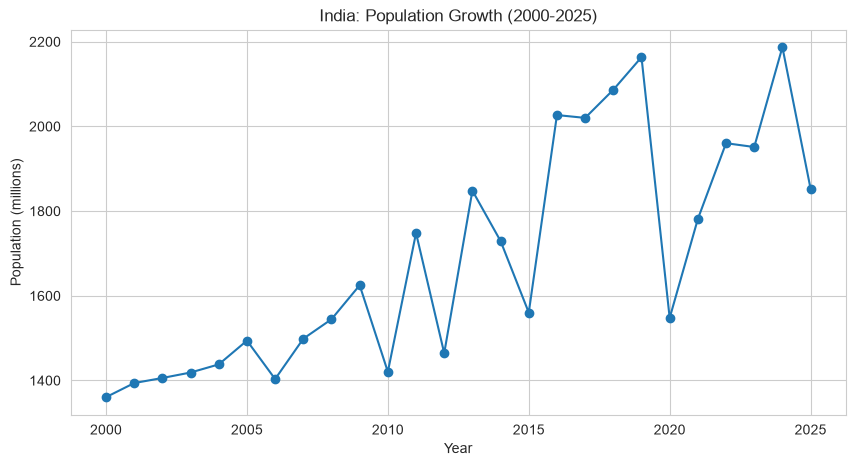

In [18]:
# Q11: Line chart — population trend for one country (e.g. India) over time
india = df[df['country'] == 'India']
plt.figure()
plt.plot(india['year'], india['population_millions'], marker='o', color='#1f77b4')
plt.title("India: Population Growth (2000-2025)")
plt.xlabel("Year")
plt.ylabel("Population (millions)")
plt.show()

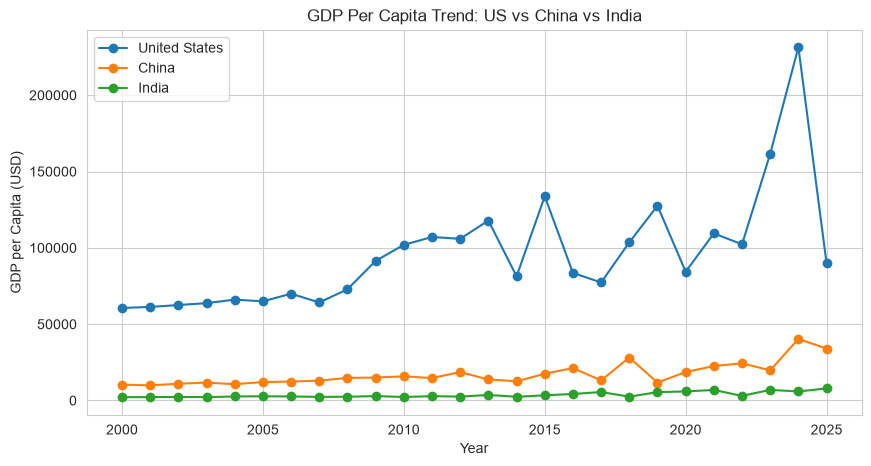

In [19]:
# Q12: Line chart comparing GDP per capita trend across 3 countries
plt.figure()
for country in ["United States", "China", "India"]:
    subset = df[df['country'] == country]
    plt.plot(subset['year'], subset['gdp_per_capita_usd'], marker='o', label=country)
plt.title("GDP Per Capita Trend: US vs China vs India")
plt.xlabel("Year")
plt.ylabel("GDP per Capita (USD)")
plt.legend()
plt.show()

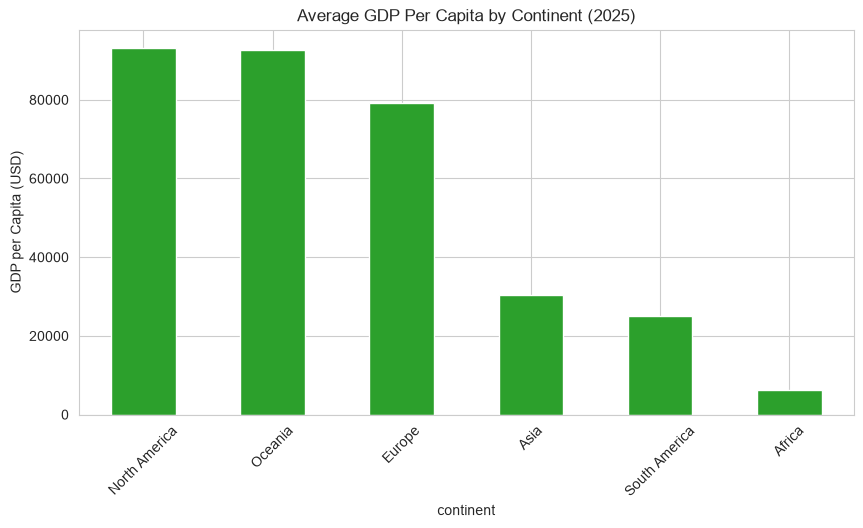

In [20]:
# Q13: Bar chart — average GDP per capita by continent (latest year)
avg_gdp_by_continent = latest.groupby('continent')['gdp_per_capita_usd'].mean().sort_values(ascending=False)
plt.figure()
avg_gdp_by_continent.plot(kind='bar', color='#2ca02c')
plt.title("Average GDP Per Capita by Continent (2025)")
plt.ylabel("GDP per Capita (USD)")
plt.xticks(rotation=45)
plt.show()

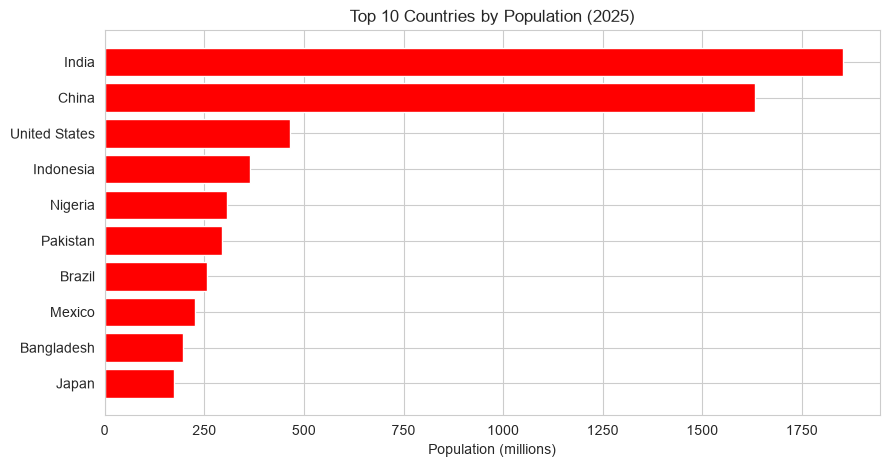

In [22]:
# Q14: Horizontal bar chart — top 10 countries by population (latest year)
top10_pop = latest.sort_values('population_millions', ascending=False).head(10)
plt.figure()
plt.barh(top10_pop['country'], top10_pop['population_millions'], color='red')
plt.title("Top 10 Countries by Population (2025)")
plt.xlabel("Population (millions)")
plt.gca().invert_yaxis()
plt.show()

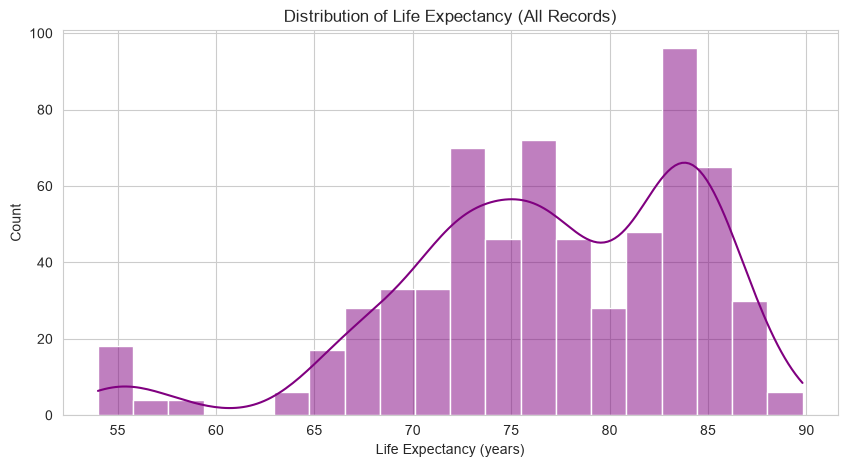

In [24]:
# Q15: Histogram of life_expectancy across all countries and years
plt.figure()
sns.histplot(df['life_expectancy'], bins=20, kde=True, color='purple')
plt.title("Distribution of Life Expectancy (All Records)")
plt.xlabel("Life Expectancy (years)")
plt.show()

AttributeError: module 'matplotlib.pyplot' has no attribute 'tight_lay'

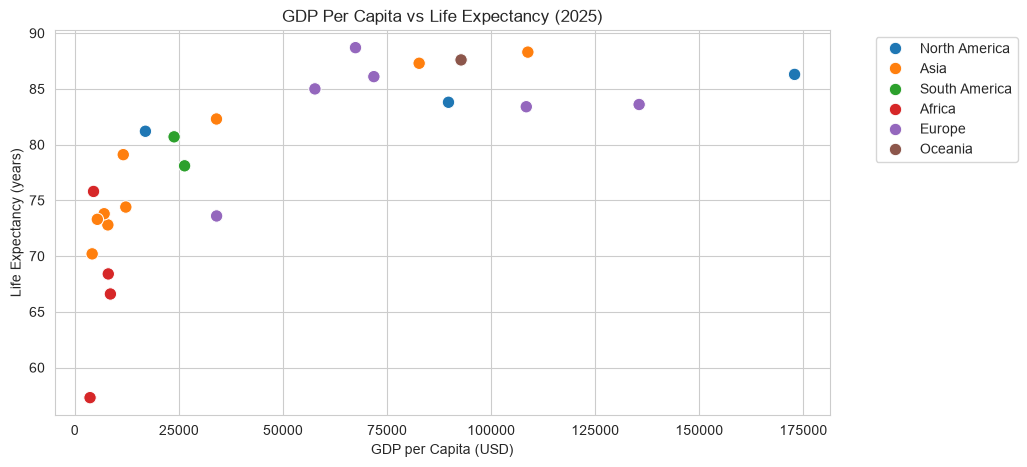

In [25]:
# Q16: Scatter plot — GDP per capita vs life expectancy (latest year)
plt.figure()
sns.scatterplot(data=latest, x='gdp_per_capita_usd', y='life_expectancy',
                 hue='continent', s=80)
plt.title("GDP Per Capita vs Life Expectancy (2025)")
plt.xlabel("GDP per Capita (USD)")
plt.ylabel("Life Expectancy (years)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_lay

C:\Users\hp\AppData\Local\Temp\ipykernel_2100\2808637155.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='continent', y='unemployment_rate_pct', palette='Set2')


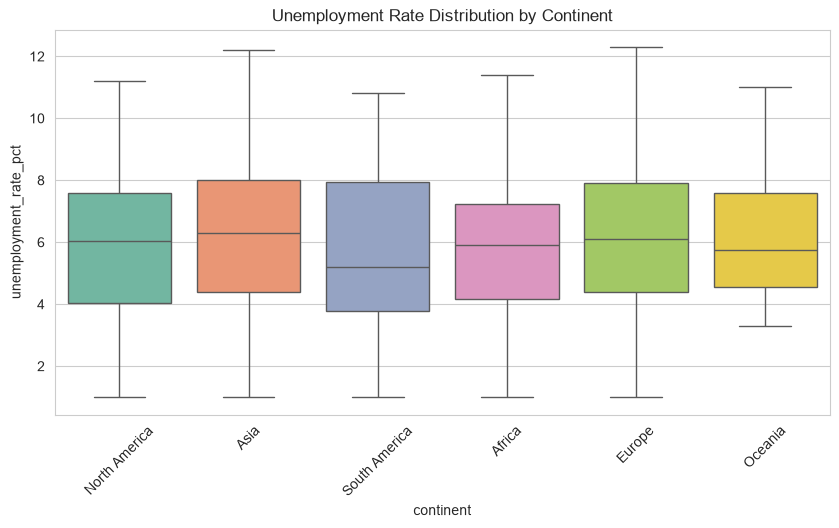

In [26]:
# Q17: Box plot — unemployment_rate_pct by continent
plt.figure()
sns.boxplot(data=df, x='continent', y='unemployment_rate_pct', palette='Set2')
plt.title("Unemployment Rate Distribution by Continent")
plt.xticks(rotation=45)
plt.show()

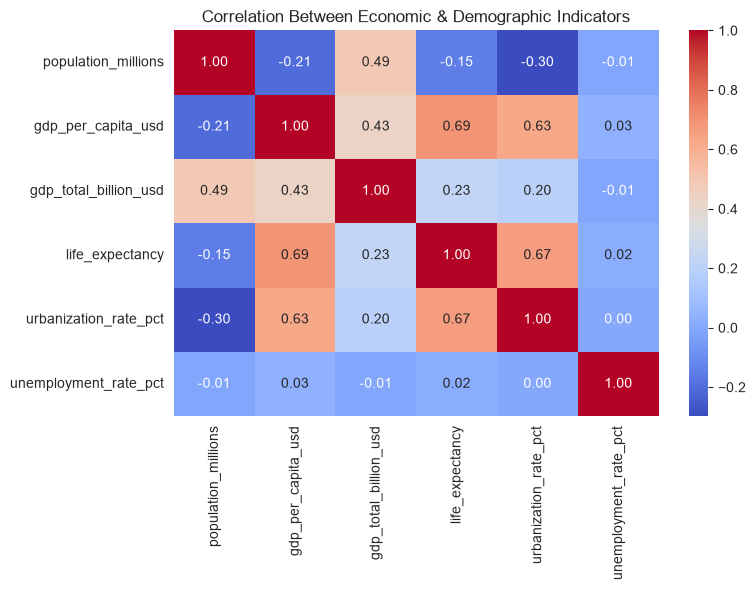

In [27]:
# Q18: Correlation heatmap of all numeric columns
numeric_cols = ['population_millions', 'gdp_per_capita_usd', 'gdp_total_billion_usd',
                 'life_expectancy', 'urbanization_rate_pct', 'unemployment_rate_pct']
plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Between Economic & Demographic Indicators")
plt.tight_layout()
plt.show()

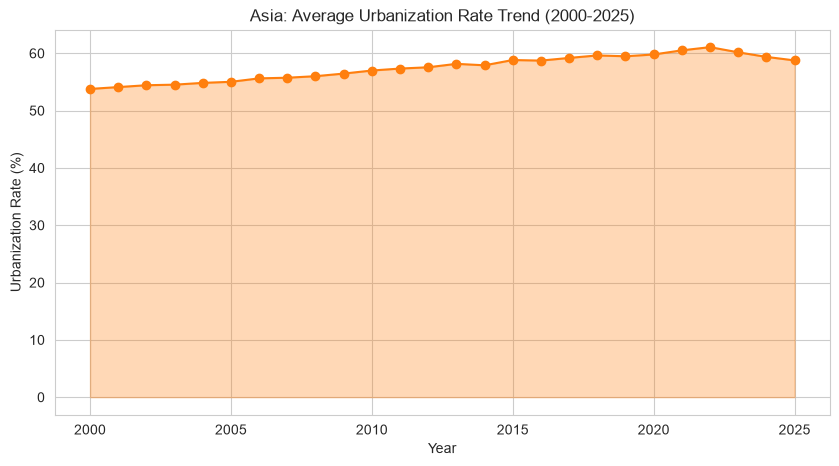

In [29]:
# Q19: Area/line chart showing urbanization_rate_pct trend for one continent's average, over time
asia_urban_trend = df[df['continent'] == 'Asia'].groupby('year')['urbanization_rate_pct'].mean()
plt.figure()
plt.plot(asia_urban_trend.index, asia_urban_trend.values, color='#ff7f0e', marker='o')
plt.fill_between(asia_urban_trend.index, asia_urban_trend.values, alpha=0.3, color='#ff7f0e')
plt.title("Asia: Average Urbanization Rate Trend (2000-2025)")
plt.xlabel("Year")
plt.ylabel("Urbanization Rate (%)")
plt.show()
 

Text(0.5, 1.0, 'India Population Growth')

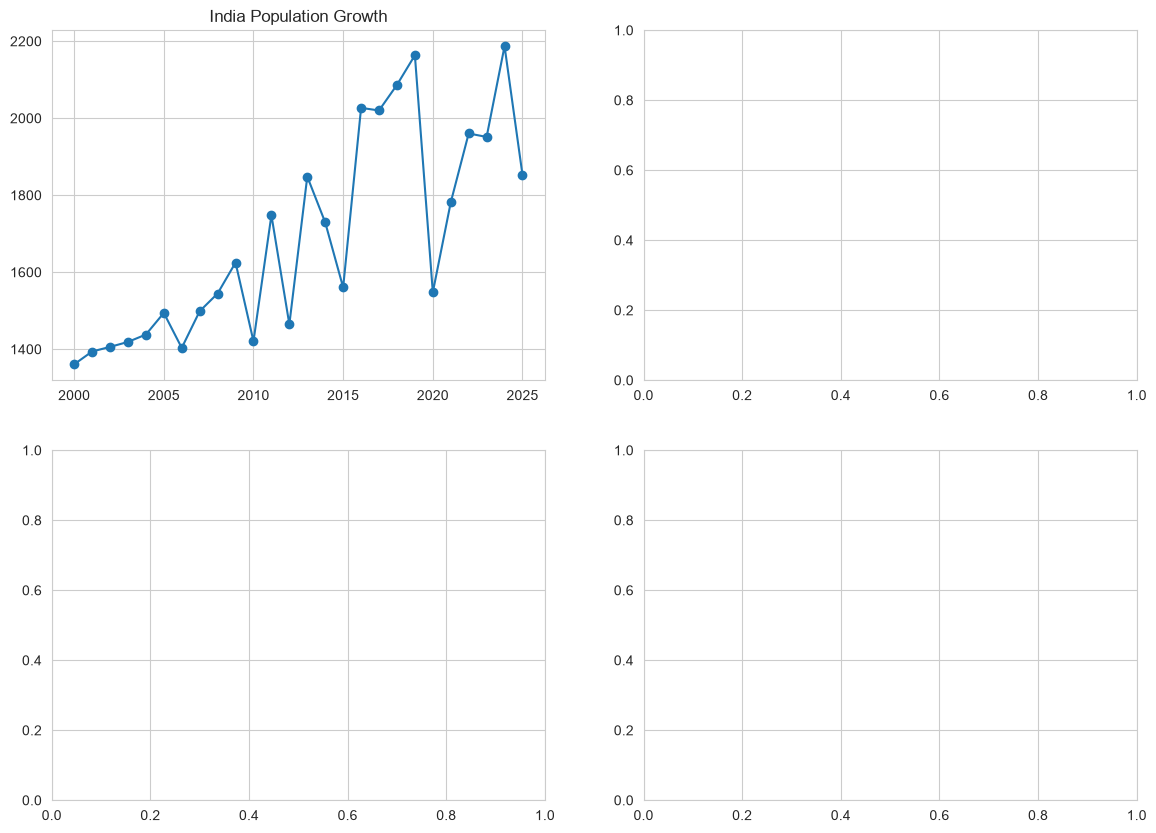

In [30]:
# Q20: 2x2 dashboard combining 4 key charts
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
 
# Panel 1: Population trend for India
axes[0, 0].plot(india['year'], india['population_millions'], marker='o', color='#1f77b4')
axes[0, 0].set_title("India Population Growth")


In [31]:
# Panel 2: GDP per capita by continent
avg_gdp_by_continent.plot(kind='bar', color='#2ca02c', ax=axes[0, 1])
axes[0, 1].set_title("Avg GDP Per Capita by Continent (2025)")
axes[0, 1].tick_params(axis='x', rotation=45)

In [32]:
# Panel 3: Life expectancy distribution
sns.histplot(df['life_expectancy'], bins=20, kde=True, color='#9467bd', ax=axes[1, 0])
axes[1, 0].set_title("Life Expectancy Distribution")

Text(0.5, 1.0, 'Life Expectancy Distribution')

In [34]:
# Panel 4: GDP vs Life expectancy scatter
sns.scatterplot(data=latest, x='gdp_per_capita_usd', y='life_expectancy',
                 hue='continent', s=60, ax=axes[1, 1], legend=False)
axes[1, 1].set_title("GDP vs Life Expectancy (2025)")
 
plt.tight_layout()
plt.savefig("global_economy_dashboard.png", dpi=150)
plt.show()
 

 

<Figure size 1000x500 with 0 Axes>

In [35]:
#  GENERAL QUERIES
# Q21: Print all unique country names in the dataset.
print(df['country'].unique())

<StringArray>
[ 'United States',          'China',          'India',         'Brazil',
        'Nigeria',        'Germany', 'United Kingdom',         'France',
          'Japan',    'South Korea',         'Mexico',         'Canada',
   'South Africa',          'Egypt',      'Indonesia',         'Russia',
      'Australia',          'Italy',          'Spain',      'Argentina',
          'Kenya',     'Bangladesh',       'Pakistan',        'Vietnam',
    'Philippines']
Length: 25, dtype: str


In [36]:
 # Q22: Print all unique continent names.

print(df['continent'].unique())

<StringArray>
['North America', 'Asia', 'South America', 'Africa', 'Europe', 'Oceania']
Length: 6, dtype: str


In [37]:
# Q23: Find how many rows belong to each continent.
print(df['continent'].value_counts())

continent
Asia             234
Europe           156
Africa           104
North America     78
South America     52
Oceania           26
Name: count, dtype: int64


In [38]:
# Q24: Filter the dataset to show only rows for the year 2025.
year_2025 = df[df['year'] == 2025]
print(year_2025.head())

           country      continent  year  population_millions  \
25   United States  North America  2025               466.27   
51           China           Asia  2025              1631.15   
77           India           Asia  2025              1852.76   
103         Brazil  South America  2025               257.93   
129        Nigeria         Africa  2025               306.92   

     gdp_per_capita_usd  gdp_total_billion_usd  life_expectancy  \
25              89749.0                41847.0             83.8   
51              34016.9                55486.7             82.3   
77               7925.6                14684.2             72.8   
103             23838.4                 6148.6             80.7   
129              3647.1                 1119.4             57.3   

     urbanization_rate_pct  unemployment_rate_pct  
25                    90.8                    9.3  
51                    65.3                    4.4  
77                    44.3                    1.6  
103 

In [39]:
# Q25: Filter the dataset to show only India's data across all years.

india_data = df[df['country'] == 'India']
print(india_data[['year', 'population_millions', 'gdp_per_capita_usd']])

    year  population_millions  gdp_per_capita_usd
52  2000              1360.62              2179.3
53  2001              1393.92              2205.6
54  2002              1405.91              2311.6
55  2003              1418.80              2179.0
56  2004              1437.97              2645.9
57  2005              1494.15              2752.3
58  2006              1403.37              2636.4
59  2007              1498.60              2364.5
60  2008              1544.61              2466.0
61  2009              1624.91              2881.7
62  2010              1420.47              2294.3
63  2011              1748.19              2835.1
64  2012              1464.45              2522.7
65  2013              1848.26              3631.2
66  2014              1729.28              2436.5
67  2015              1560.39              3376.6
68  2016              2026.79              4256.3
69  2017              2020.06              5554.0
70  2018              2086.45              2491.2


In [40]:
# Q26: Find the average life_expectancy across the entire dataset.

print("Average life expectancy:", df['life_expectancy'].mean())

Average life expectancy: 76.87107692307691


In [41]:
# Q27: Find the maximum and minimum population_millions
# recorded in the dataset.

print("Max population:", df['population_millions'].max())
print("Min population:", df['population_millions'].min())

Max population: 2452.48
Min population: 24.93


In [42]:
# Q28: Sort the dataset by gdp_per_capita_usd in descending order
# and show the top 10 rows.

top10 = df.sort_values('gdp_per_capita_usd', ascending=False).head(10)
print(top10[['country', 'year', 'gdp_per_capita_usd']])

            country  year  gdp_per_capita_usd
24    United States  2024            231466.1
440       Australia  2024            207438.1
311          Canada  2025            172884.2
438       Australia  2022            166310.1
310          Canada  2024            163505.9
23    United States  2023            161639.2
232           Japan  2024            156097.6
152         Germany  2022            154371.3
307          Canada  2021            147009.7
180  United Kingdom  2024            142886.7


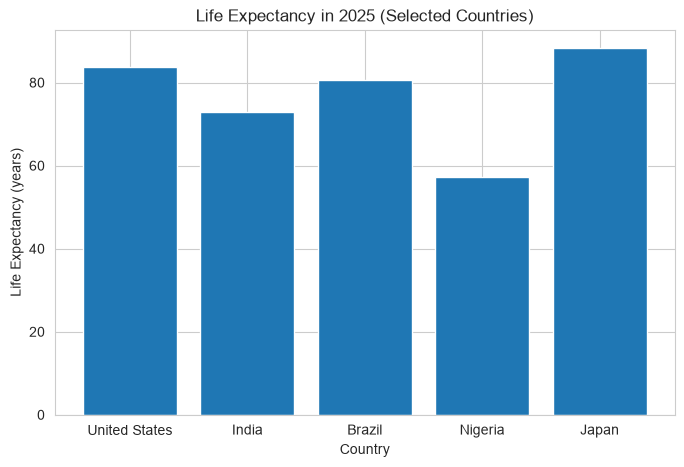

In [43]:
# Q29: Create a simple bar chart showing life_expectancy
# for 5 selected countries in the year 2025.

selected = df[(df['year'] == 2025) &
              (df['country'].isin(['India', 'United States', 'Japan', 'Nigeria', 'Brazil']))]
 
plt.figure(figsize=(8, 5))
plt.bar(selected['country'], selected['life_expectancy'], color='#1f77b4')
plt.title("Life Expectancy in 2025 (Selected Countries)")
plt.xlabel("Country")
plt.ylabel("Life Expectancy (years)")
plt.show()

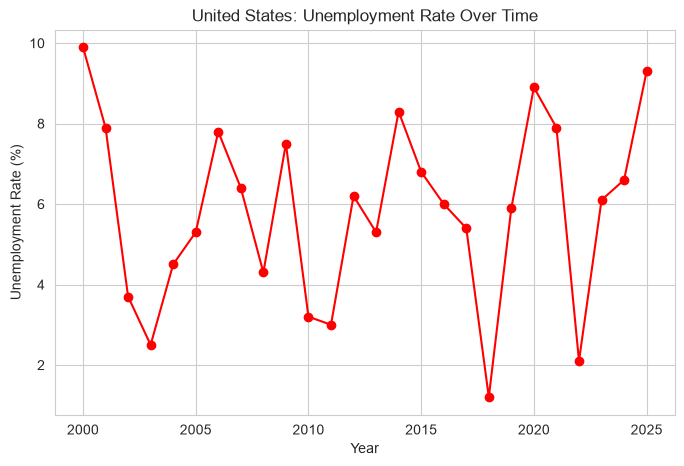

In [44]:
# Q30: Create a simple line chart showing unemployment_rate_pct for the United States over the years.

us_data = df[df['country'] == 'United States']
 
plt.figure(figsize=(8, 5))
plt.plot(us_data['year'], us_data['unemployment_rate_pct'], marker='o', color='red')
plt.title("United States: Unemployment Rate Over Time")
plt.xlabel("Year")
plt.ylabel("Unemployment Rate (%)")
plt.show()